In [67]:
from collections import deque
import random
import time
from typing import List, Set, Tuple, Dict, Optional

# BFS Implementation
def bfs(graph, start_node, target_node=None):
    """Breadth-First Search on graph"""
    visited = set()
    queue = deque([(start_node, [start_node])])

    while queue:
        current_node, path = queue.popleft()

        if current_node == target_node:
            return path

        if current_node not in visited:
            visited.add(current_node)

            for neighbor in graph.get(current_node, []):
                if neighbor not in visited:
                    new_path = path + [neighbor]
                    queue.append((neighbor, new_path))

    return []

#DFS Implementation
def dfs(graph, start_node, target_node=None, path=None, visited=None):
    """Depth-First Search on graph"""
    if path is None:
        path = []
    if visited is None:
        visited = set()

    path.append(start_node)
    visited.add(start_node)

    if start_node == target_node:
        return path

    for neighbor in graph.get(start_node, []):
        if neighbor not in visited:
            result = dfs(graph, neighbor, target_node, path.copy(), visited)
            if result and target_node in result:
                return result

    return []

In [68]:
#Maze Generation
def generate_maze(width, height):
    maze = [['#' for _ in range(width)] for _ in range(height)]
    start_x, start_y = random.randint(0, width // 2) * 2, random.randint(0, height // 2) * 2

    if start_x % 2 != 0: start_x -= 1
    if start_y % 2 != 0: start_y -= 1
    if start_x < 0: start_x = 0
    if start_y < 0: start_y = 0

    maze[start_y][start_x] = 'S'

    visited = set()
    stack = [(start_x, start_y)]
    visited.add((start_x, start_y))

    while stack:
        current_x, current_y = stack[-1]
        neighbors = []

        directions = [(0, 2), (0, -2), (2, 0), (-2, 0)]
        random.shuffle(directions)

        for dx, dy in directions:
            nx, ny = current_x + dx, current_y + dy
            if 0 <= nx < width and 0 <= ny < height and (nx, ny) not in visited:
                neighbors.append(((nx, ny), (current_x + dx // 2, current_y + dy // 2)))

        if neighbors:
            (next_x, next_y), (wall_x, wall_y) = random.choice(neighbors)

            if maze[wall_y][wall_x] == '#':
                maze[wall_y][wall_x] = '.'
            if maze[next_y][next_x] == '#':
                maze[next_y][next_x] = '.'

            visited.add((next_x, next_y))
            stack.append((next_x, next_y))
        else:
            stack.pop()

    empty_cells = []
    for r in range(height):
        for c in range(width):
            if maze[r][c] == '.':
                empty_cells.append((c, r))

    if empty_cells:
        end_x, end_y = random.choice(empty_cells)
        maze[end_y][end_x] = 'E'

    return maze

def print_maze(maze):
    for row in maze:
        print(''.join(row))


In [69]:
class MazeSolver:
    """Solves mazes using BFS and DFS algorithms"""

    def __init__(self, maze):
        self.maze = [row[:] for row in maze]  # Deep copy
        self.height = len(maze)
        self.width = len(maze[0]) if maze else 0
        self.start = self.find_point('S')
        self.end = self.find_point('E')

    def find_point(self, marker):
        """Find start (S) or end (E) point in maze"""
        for r in range(self.height):
            for c in range(self.width):
                if self.maze[r][c] == marker:
                    return (c, r)
        return None

    def get_neighbors(self, pos):
        """Get valid neighbors for a position (4-directional: up, down, left, right)"""
        x, y = pos
        neighbors = []
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # down, up, right, left

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < self.width and 0 <= ny < self.height:
                if self.maze[ny][nx] != '#':
                    neighbors.append((nx, ny))
        return neighbors

    def solve_bfs(self):
        """Solve maze using BFS (guaranteed shortest path)"""
        if not self.start or not self.end:
            return None, 0, 0

        visited = {self.start}
        queue = deque([(self.start, [self.start])])
        nodes_explored = 0

        while queue:
            current, path = queue.popleft()
            nodes_explored += 1

            if current == self.end:
                return path, len(path) - 1, nodes_explored  # path length is steps

            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, path + [neighbor]))

        return None, 0, nodes_explored

    def solve_dfs(self):
        """Solve maze using DFS (may not find shortest path)"""
        if not self.start or not self.end:
            return None, 0, 0

        visited = set()
        nodes_explored = [0]  # Use list to allow modification in nested function

        def dfs_helper(current, path):
            visited.add(current)
            nodes_explored[0] += 1

            if current == self.end:
                return path

            for neighbor in self.get_neighbors(current):
                if neighbor not in visited:
                    result = dfs_helper(neighbor, path + [neighbor])
                    if result:
                        return result

            return None

        path = dfs_helper(self.start, [self.start])
        if path:
            return path, len(path) - 1, nodes_explored[0]
        return None, 0, nodes_explored[0]

    def visualize_path(self, path, marker='-'):
        maze_copy = [row[:] for row in self.maze]
        if path:
            for x, y in path[1:-1]:
                if maze_copy[y][x] not in ('S', 'E'):
                    maze_copy[y][x] = marker
        return maze_copy

    def print_solved_maze(self, path, marker='-'):
        visual_maze = self.visualize_path(path, marker)
        for row in visual_maze:
            print(''.join(row))

In [70]:
class BiDirectionalSearch:
    """Implements bi-directional BFS and DFS for route finding"""

    def __init__(self, maze):
        self.maze = [row[:] for row in maze]
        self.height = len(maze)
        self.width = len(maze[0]) if maze else 0
        self.start = self.find_point('S')
        self.end = self.find_point('E')

    def find_point(self, marker):
        for r in range(self.height):
            for c in range(self.width):
                if self.maze[r][c] == marker:
                    return (c, r)
        return None

    def get_neighbors(self, pos):
        x, y = pos
        neighbors = []
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < self.width and 0 <= ny < self.height:
                if self.maze[ny][nx] != '#':
                    neighbors.append((nx, ny))
        return neighbors

    def bi_directional_bfs(self):
        """Bi-directional BFS - search from both start and end"""
        if not self.start or not self.end:
            return None, 0, 0

        # Two frontiers
        forward_visited = {self.start: [self.start]}
        backward_visited = {self.end: [self.end]}

        forward_queue = deque([self.start])
        backward_queue = deque([self.end])

        nodes_explored = 0

        while forward_queue or backward_queue:
            # Expand from start side
            if forward_queue:
                current = forward_queue.popleft()
                nodes_explored += 1

                for neighbor in self.get_neighbors(current):
                    if neighbor in backward_visited:
                        # Found connection!
                        path = forward_visited[current] + backward_visited[neighbor][::-1]
                        return path, len(path) - 1, nodes_explored

                    if neighbor not in forward_visited:
                        forward_visited[neighbor] = forward_visited[current] + [neighbor]
                        forward_queue.append(neighbor)

            # Expand from end side
            if backward_queue:
                current = backward_queue.popleft()
                nodes_explored += 1

                for neighbor in self.get_neighbors(current):
                    if neighbor in forward_visited:
                        # Found connection!
                        path = forward_visited[neighbor] + backward_visited[current][::-1]
                        return path, len(path) - 1, nodes_explored

                    if neighbor not in backward_visited:
                        backward_visited[neighbor] = backward_visited[current] + [neighbor]
                        backward_queue.append(neighbor)

        return None, 0, nodes_explored

    def bi_directional_dfs(self):

        if not self.start or not self.end:
            return None, 0, 0

        forward_visited = {self.start: [self.start]}
        backward_visited = {self.end: [self.end]}

        forward_stack = [self.start]
        backward_stack = [self.end]

        nodes_explored = [0]

        def explore_forward():
            if not forward_stack:
                return None

            current = forward_stack.pop()
            nodes_explored[0] += 1

            for neighbor in self.get_neighbors(current):
                if neighbor in backward_visited:
                    return forward_visited[current] + backward_visited[neighbor][::-1]

                if neighbor not in forward_visited:
                    forward_visited[neighbor] = forward_visited[current] + [neighbor]
                    forward_stack.append(neighbor)

            return None

        def explore_backward():
            if not backward_stack:
                return None

            current = backward_stack.pop()
            nodes_explored[0] += 1

            for neighbor in self.get_neighbors(current):
                if neighbor in forward_visited:
                    return forward_visited[neighbor] + backward_visited[current][::-1]

                if neighbor not in backward_visited:
                    backward_visited[neighbor] = backward_visited[current] + [neighbor]
                    backward_stack.append(neighbor)

            return None

        # Alternate between forward and backward
        while forward_stack or backward_stack:
            result = explore_forward()
            if result:
                return result, len(result) - 1, nodes_explored[0]

            result = explore_backward()
            if result:
                return result, len(result) - 1, nodes_explored[0]

        return None, 0, nodes_explored[0]

In [71]:
# Generate a test maze
print("GENERATING MAZE (25x25)")
maze = generate_maze(25, 25)
print("\nGenerated Maze:")
print_maze(maze)


GENERATING MAZE (25x25)

Generated Maze:
...........#.......#.....
.#########.#.#.###.###.#.
...#.....#.#.#...#...#.#.
##.#.#####.#####.###.###.
.#...#S..#.#...#...#.....
.###.###.#.#E#.###.#####.
...#.#.#.#.#.#.#...#...#.
.###.#.#.#.#.#.#.###.#.#.
...#...#...#.#...#...#.#.
.#.###.#####.#########.#.
.#...#.#.......#.....#...
.#.#.#.###.###.#.###.###.
.#.#.#...#.#...#.#.#...#.
##.#.###.###.###.#.###.##
...#...#...#.#...#...#...
.#####.###.#.#.###.#.###.
.#...#...#.#.#...#.#...#.
.#.#.#####.#.###.#####.#.
.#.#.....#.#.......#...#.
.#.#####.#.#.#####.#.###.
.#...#.#.#.#.#...#...#...
.###.#.#.#.###.#.#####.#.
...#.#.#.#...#.#.#.....#.
.###.#.#.###.#.#.#.#####.
.......#.......#...#.....


In [72]:
# PART 1: Test Maze Solver with BFS and DFS

print("PART 1: MAZE SOLVER (BFS vs DFS)")


solver = MazeSolver(maze)

print("\n[1] BREADTH-FIRST SEARCH (BFS)")
print("-" * 40)
start_time = time.time()
bfs_path, bfs_length, bfs_explored = solver.solve_bfs()
bfs_time = time.time() - start_time

print(f"Path found: {bfs_path is not None}")
if bfs_path:
    print(f"Path length (steps): {bfs_length}")
print(f"Nodes explored: {bfs_explored}")
print(f"Time taken: {bfs_time*1000:.4f} ms")

print("\nBFS Solved Maze (marked with '---'):")
solver.print_solved_maze(bfs_path, '-')

print("\n[2] DEPTH-FIRST SEARCH (DFS)")
print("-" * 40)
start_time = time.time()
dfs_path, dfs_length, dfs_explored = solver.solve_dfs()
dfs_time = time.time() - start_time

print(f"Path found: {dfs_path is not None}")
if dfs_path:
    print(f"Path length (steps): {dfs_length}")
print(f"Nodes explored: {dfs_explored}")
print(f"Time taken: {dfs_time*1000:.4f} ms")

print("\nDFS Solved Maze (marked with '___'):")
solver.print_solved_maze(dfs_path, '_')


PART 1: MAZE SOLVER (BFS vs DFS)

[1] BREADTH-FIRST SEARCH (BFS)
----------------------------------------
Path found: True
Path length (steps): 137
Nodes explored: 266
Time taken: 0.6464 ms

BFS Solved Maze (marked with '---'):
-----------#.......#.....
-#########-#.#.###.###.#.
---#.....#-#.#...#...#.#.
##-#.#####-#####.###.###.
.#---#S--#-#...#...#.....
.###-###-#-#E#.###.#####.
...#-#.#-#-#-#.#...#...#.
.###-#.#-#-#-#.#.###.#.#.
...#---#---#-#...#...#.#.
.#.###-#####-#########.#.
.#...#-#....---#-----#...
.#.#.#-###.###-#-###-###.
.#.#.#---#.#---#-#.#---#.
##.#.###-###-###-#.###-##
...#...#---#-#---#...#---
.#####.###-#-#-###.#.###-
.#...#...#-#-#---#.#...#-
.#.#.#####-#-###-#####.#-
.#.#.....#-#-----..#...#-
.#.#####.#-#.#####.#.###-
.#...#.#.#-#.#---#...#---
.###.#.#.#-###-#-#####-#.
...#.#.#.#---#-#-#-----#.
.###.#.#.###-#-#-#-#####.
.......#....---#---#.....

[2] DEPTH-FIRST SEARCH (DFS)
----------------------------------------
Path found: True
Path length (steps): 137
Nodes exp

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def maze_to_array(maze):
    h = len(maze)
    w = len(maze[0])
    arr = np.zeros((h, w))
    for y in range(h):
        for x in range(w):
            if maze[y][x] == '#':
                arr[y, x] = 0
            elif maze[y][x] == 'S':
                arr[y, x] = 2
            elif maze[y][x] == 'E':
                arr[y, x] = 3
            else:
                arr[y, x] = 1
    return arr


def plot_maze_bfs(maze, bfs_path):
    arr = maze_to_array(maze)
    cmap = ListedColormap(['black', 'white', 'green', 'red'])

    plt.figure(figsize=(7, 7))
    plt.imshow(arr, cmap=cmap)
    if bfs_path:
        bx = [x for x, y in bfs_path]
        by = [y for x, y in bfs_path]
        plt.plot(bx, by, color='blue', linewidth=3)
    plt.title("Breadth-First Search (BFS) Path", fontsize=14)
    plt.axis('off')
    plt.show()


def plot_maze_dfs(maze, dfs_path):
    arr = maze_to_array(maze)
    cmap = ListedColormap(['black', 'white', 'green', 'red'])

    plt.figure(figsize=(7, 7))
    plt.imshow(arr, cmap=cmap)
    if dfs_path:
        dx = [x for x, y in dfs_path]
        dy = [y for x, y in dfs_path]
        plt.plot(dx, dy, color='orange', linewidth=3)
    plt.title("Depth-First Search (DFS) Path", fontsize=14)
    plt.axis('off')
    plt.show()


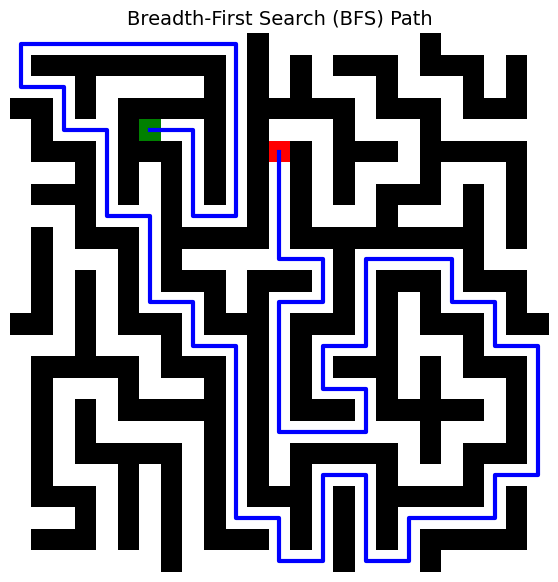

In [74]:
plot_maze_bfs(maze, bfs_path)



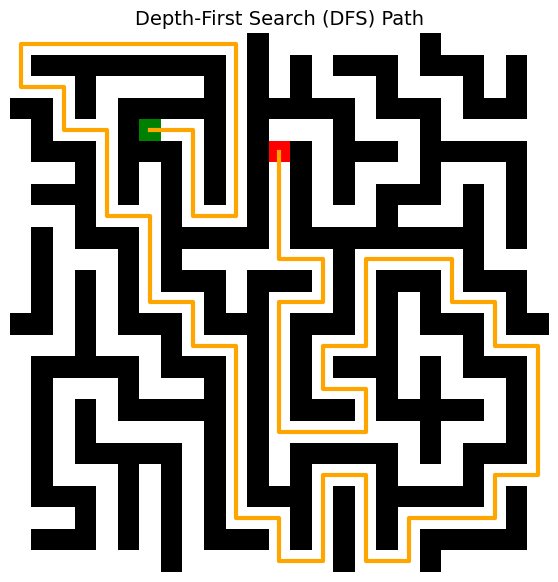

In [75]:
plot_maze_dfs(maze, dfs_path)